More results that Mike asked for.

In [1]:
grid_file = '/home/benr/src/ssm-analysis/SSM_Grid/ssm_grid.2dm'

import configparser
import re
import os

from netCDF4 import Dataset
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from fvcom import FvcomGrid, Transect, ControlVolume

In [2]:
data = Dataset('results/doxg.nc')
data

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    model_start: 2014-01-01 00:00:00
    dimensions(sizes): time(4380), node(3137), nele(4129), siglay(10), siglev(11)
    variables(dimensions): int32 node(node), float32 h(node), float32 x(node), float32 y(node), int32 nele(nele), float32 time(time), float32 siglay(siglay), float32 siglev(siglev), float32 zeta(time, node), float32 controlDOXG(time, siglay, node), float32 c2936DOXG(time, siglay, node), float32 q1c454DOXG(time, siglay, node), float32 q1c10DOXG(time, siglay, node), float32 q1c15DOXG(time, siglay, node), float32 q1c20DOXG(time, siglay, node), float32 q1c25DOXG(time, siglay, node), float32 q1c2936DOXG(time, siglay, node), float32 q3c454DOXG(time, siglay, node), float32 q3c10DOXG(time, siglay, node), float32 q3c15DOXG(time, siglay, node), float32 q3c20DOXG(time, siglay, node), float32 q3c25DOXG(time, siglay, node), float32 q3c2936DOXG(time, siglay, node), float32 q5c454DOXG(time, siglay, 

In [3]:
def sort(vs):
    r = re.compile('q([1-9])c([0-9]+)')
    dec = []
    for v in vs:
        if v[-4:] != 'DOXG':
            continue
        n = v[:-4] # Remove 'DOXG'
        m = r.match(n)
        if m:
            q = m.group(1)
            c = m.group(2)
            if c == '454':
                c = '0' + c
        else:
            if n == 'control':
                q = '0'
                c = '0'
            else:
                q = '0'
                c = '1'
        dec.append((q, c, v))
    dec.sort()
    return [v for q, c, v in dec]

sort(data.variables)

['controlDOXG',
 'c2936DOXG',
 'q1c454DOXG',
 'q1c10DOXG',
 'q1c15DOXG',
 'q1c20DOXG',
 'q1c25DOXG',
 'q1c2936DOXG',
 'q3c454DOXG',
 'q3c10DOXG',
 'q3c15DOXG',
 'q3c20DOXG',
 'q3c25DOXG',
 'q3c2936DOXG',
 'q5c454DOXG',
 'q5c10DOXG',
 'q5c15DOXG',
 'q5c20DOXG',
 'q5c25DOXG',
 'q5c2936DOXG',
 'q7c454DOXG',
 'q7c10DOXG',
 'q7c15DOXG',
 'q7c20DOXG',
 'q7c25DOXG',
 'q7c2936DOXG',
 'q9c454DOXG',
 'q9c10DOXG',
 'q9c15DOXG',
 'q9c20DOXG',
 'q9c25DOXG',
 'q9c2936DOXG']

Get the tenth percentile DO across Puget Sound, as the minimum of the water column at any given location.

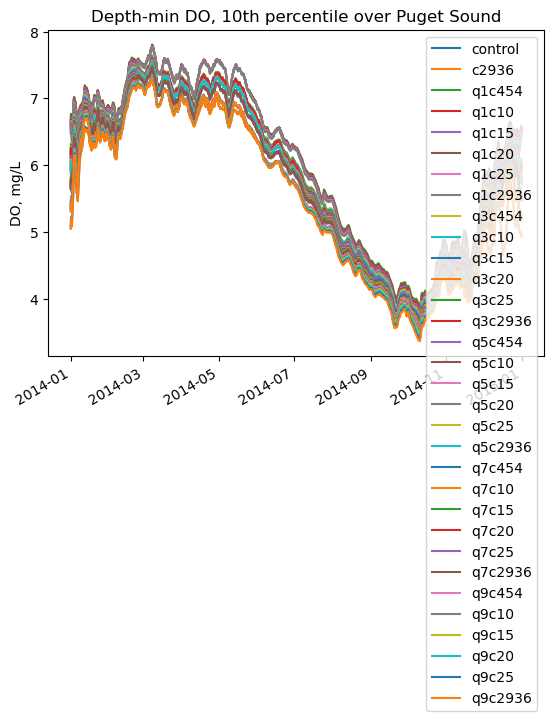

In [4]:
dates = pd.Timestamp(data.model_start) + pd.to_timedelta(data['time'][:], 'D')
fig, ax = plt.subplots()
mindo_10pct = {}
for v in sort(data.variables):
    name = v[:-4]
    ser = pd.Series(np.quantile(data[v][:].data.min(axis=1), 0.1, axis=1), index=dates)
    ser.rolling('1D').mean().plot(ax=ax, label=name)
    mindo_10pct[name] = ser
mindo_10pct_df = pd.DataFrame(mindo_10pct)
ax.set(title='Depth-min DO, 10th percentile over Puget Sound', ylabel='DO, mg/L')
ax.legend()

In [5]:
mindo_10pct_df.to_excel('results/puget_sound/do_min_10pct.xlsx')

Get the mean bottom DO and hypoxic area for just Hood Canal

In [6]:
grid = FvcomGrid.from_mesh(grid_file)
areas = grid.tces_gdf().loc[data['node'][:]].area
areas

4478     1.290208e+06
4479     1.012244e+06
4480     1.511056e+06
4481     1.856297e+06
4482     1.190541e+06
             ...     
15989    2.452663e+05
15993    2.198963e+05
15994    1.809223e+05
16000    9.728483e+04
16003    2.510567e+05
Length: 3137, dtype: float64

In [7]:
master_sections = '/home/benr/src/ssm-analysis/SSM_Grid/sections.ini'
master_sections_config = configparser.ConfigParser()
master_sections_config.read(master_sections)

hc_waypoints = np.array(master_sections_config['HoodCanalEntrance']['waypoints'].split(' ')).astype(int)
hc_transect = Transect.shortest(grid, hc_waypoints)
hc_cv = ControlVolume(grid=hc_transect.grid,
                      nodes=ControlVolume.from_transects([hc_transect]).nodes & set(data['node'][:]),
                      calc=True)
if not os.path.isdir(f'results/hoodcanal'):
    os.mkdir(f'results/hoodcanal')

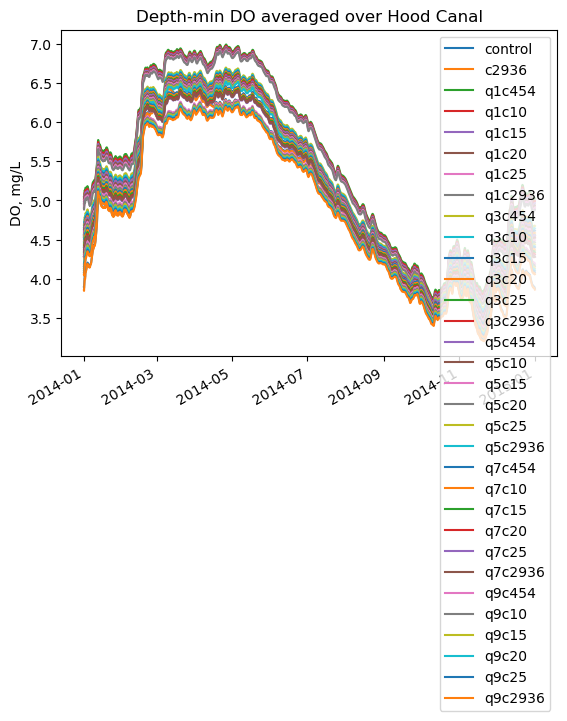

In [8]:
fig, ax = plt.subplots()
mindo_avgs_hc = {}
idxs = np.searchsorted(data['node'][:], np.array(list(hc_cv.nodes)))
for v in sort(data.variables):
    name = v[:-4]
    ser = pd.Series(np.average(data[v][:,:,idxs].min(axis=1), axis=1, weights=areas.iloc[idxs]), index=dates)
    ser.rolling('1D').mean().plot(ax=ax, label=name)
    mindo_avgs_hc[name] = ser
mindo_avgs_hc_df = pd.DataFrame(mindo_avgs_hc)
ax.set(title=f'Depth-min DO averaged over Hood Canal', ylabel='DO, mg/L')
ax.legend()

In [9]:
mindo_avgs_hc_df.to_excel('results/hoodcanal/do_min_avg.xlsx')

In [11]:
def extract_bottom_cv(v, cv):
    idxs = np.searchsorted(data['node'][:], np.array(list(cv.nodes)))
    return data[v][:,-1,idxs].data

def calc_cv_area(data, t, cv):
    return cv.tces.loc[data[t,:] < 2].area.sum() / 1e6

hc_bottom_hypoxic_areas = {}
for v in sort(data.variables):
    d = extract_bottom_cv(v, hc_cv)
    hc_bottom_hypoxic_areas[v] = np.zeros(d.shape[0])
    for t in range(d.shape[0]):
        hc_bottom_hypoxic_areas[v][t] = calc_cv_area(d, t, hc_cv)

# Assemble a DataFrame of all the hypoxic area timeseries for each variable
hc_bottom_hypoxic_areas_df = pd.DataFrame(hc_bottom_hypoxic_areas, index=dates)

In [12]:
hc_bottom_hypoxic_areas_df.to_excel("results/hoodcanal/bottom_hypoxic_area_km2.xlsx")

Compute hypoxic area by inlet

In [13]:
sections_file = 'inlet_sections_aurora.ini'
sections_config = configparser.ConfigParser()
sections_config.read(sections_file)

# names of sections that bound each control volume
cv_bounds = {
    'Penn Cove': ['PennCove'],
    'Holmes Harbor': ['HolmesHbr'],
    'Crescent Bay': ['CrescentBy'],
    'Carr Inlet': ['CarrInl'],
    'Case Inlet': ['CaseInl'],
    'Elliot Bay': ['ElliotBy'],
    'Commencement Bay': ['CommenceBy'],
    'Dabob Bay': ['DabobBy'],
    'Port Susan': ['PtSusan','StillaguamishSouthFork','StillaguamishPassSouth'],
    'Dyes Inlet': ['DyesInl'],
    'Sinclair Inlet': ['SinclairInl'],
    'Quartermaster Harbor': ['QtrHbr'],
    'Lynch Cove': ['LynchCove']
}

In [14]:
dirname = lambda n: n.lower().replace(' ', '_')

cvs = {}
for name, sectnames in cv_bounds.items():
    transects = []
    display(name)
    for sn in sectnames:
        waypoints = np.array(sections_config[sn]['waypoints'].split(' ')).astype(int)
        t = Transect.shortest(grid, waypoints)
        transects.append(t)
    cvs[name] = ControlVolume.from_transects(transects, calc=True)
    if not os.path.isdir(f'results/{dirname(name)}'):
        os.mkdir(f'results/{dirname(name)}')
    display(len(cvs[name].nodes))

'Penn Cove'

14

'Holmes Harbor'

26

'Crescent Bay'

...

16

'Quartermaster Harbor'

40

'Lynch Cove'

96

In [15]:
bottom_hypoxic_areas_by_cv = {}
for cvname,cv in cvs.items():
    bottom_hypoxic_areas = {}
    for v in sort(data.variables):
        d = extract_bottom_cv(v, cv)
        bottom_hypoxic_areas[v] = np.zeros(d.shape[0])
        for t in range(d.shape[0]):
            bottom_hypoxic_areas[v][t] = calc_cv_area(d, t, cv)
    bottom_hypoxic_areas_by_cv[cvname] = pd.DataFrame(bottom_hypoxic_areas, index=dates)

In [16]:
bottom_hypoxic_areas_by_cv['Lynch Cove']

,controlDOXG,c2936DOXG,q1c454DOXG,q1c10DOXG,q1c15DOXG,q1c20DOXG,q1c25DOXG,q1c2936DOXG,q3c454DOXG,q3c10DOXG,...,q7c15DOXG,q7c20DOXG,q7c25DOXG,q7c2936DOXG,q9c454DOXG,q9c10DOXG,q9c15DOXG,q9c20DOXG,q9c25DOXG,q9c2936DOXG
2014-01-01 01:59:20.000109670,0.749124,1.493150,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-01 03:59:20.000324250,0.706632,0.979275,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-01 05:59:19.999895098,0.197883,0.772686,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-01 07:59:19.999465938,0.249082,0.249082,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-01-01 09:59:20.000324250,0.249082,0.265236,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 15:59:22.207031252,0.249082,0.249082,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-12-31 17:59:20.449218747,0.249082,0.249082,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-12-31 19:59:21.328125000,0.249082,0.249082,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-12-31 21:59:22.207031252,0.524903,0.524903,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
for cvname,df in bottom_hypoxic_areas_by_cv.items():
    df.to_excel(f"results/{dirname(cvname)}/bottom_hypoxic_area_km2.xlsx")